# Peakflo AR Analysis: Strategic Insights

**Data-Driven Collection Strategy**

## 1. The Process
Our approach is rigorous and verifiable:
1. **ETL**: Load raw data and handle timezone/date artifacts.
2. **Audit**: Verify data integrity and test core assumptions.
3. **Segmentation**: Cluster customers by *behavior* (speed), not just volume.
4. **Optimization**: Model the impact of targeted 'nudges' vs standard reminders.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')


## 2. Load and Clean Data


In [11]:
def load_and_clean_data(filepath):
    df = pd.read_csv(filepath)
    date_cols = ['issue_date', 'due_date', 'paid_on_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce').dt.tz_localize(None)
    return df

# Load Data
try:
    df = load_and_clean_data('../data/data.csv') 
except FileNotFoundError:
    df = load_and_clean_data('data/data.csv') 

print(f"Total Invoices: {len(df)}")
df.head()


Total Invoices: 17692


,id,total_amount,amount_due,issue_date,due_date,paid_on_date,payer_id
0,1,1720329,0.0,2021-11-01,2021-12-31,2022-08-22,pKey9MQ59wyF6GhjWM5p
1,2,1560727,0.0,2021-11-01,2021-12-01,2021-12-04,Ed9wuAC3RlOfWkENchdD
2,3,149600,0.0,2021-11-01,2022-02-14,2022-02-22,bPBZIvFiIE1ZbZjvuYm7
3,4,149600,0.0,2021-11-01,2022-02-14,2022-02-22,bPBZIvFiIE1ZbZjvuYm7
4,5,149600,0.0,2021-11-01,2022-02-14,2022-02-22,bPBZIvFiIE1ZbZjvuYm7


## 3. Verification of Assumptions
Before proceeding, we validate the data quality and our logical assumptions.

### Assumption 1: Data Anomalies (Amount Due > Total)
We suspected some data rows contain penalties or errors.


In [12]:
# Verification: Check for Amount Due > Total Amount
anomalies = df[df['amount_due'] > df['total_amount']]
print(f"Anomalies Found: {len(anomalies)}")

fig = px.scatter(
    df, x='total_amount', y='amount_due', 
    title='Interactive Verification: Amount Due vs Total Amount',
    hover_data=['id', 'payer_id'],
    color_discrete_sequence=['red']
)
# Add a 1:1 line
fig.add_shape(type="line", x0=0, y0=0, x1=df['total_amount'].max(), y1=df['total_amount'].max(),
    line=dict(color="Green", width=2, dash="dash")
)
fig.show()


Anomalies Found: 4559


**Observation:** 25% of invoices have balances exceeding their original amount. We proceed assuming `amount_due` is the trusted recovery target.


### Assumption 2: Payment Behavior Consistency
We assume customers establish a habit.


In [13]:
# Verification: Payment Behavior
paid_inv = df[df['paid_on_date'].notnull()].copy()
paid_inv['days_to_pay'] = (paid_inv['paid_on_date'] - paid_inv['issue_date']).dt.days

fig = px.histogram(paid_inv, x="days_to_pay", nbins=50, title="Distribution of Payment Speed (Days)")
fig.update_layout(bargap=0.1)
fig.show()


## 4. Derived Metrics & Feature Engineering (Part 2)


In [14]:
# Feature Engineering
df['days_to_pay'] = (df['paid_on_date'] - df['issue_date']).dt.days
df['days_overdue_actual'] = (df['paid_on_date'] - df['due_date']).dt.days

# Current Status
max_date = df['issue_date'].max()
analysis_date = max_date if pd.notnull(max_date) else datetime.now()

conditions = [
    (pd.notnull(df['paid_on_date'])), 
    (pd.isnull(df['paid_on_date']) & (df['due_date'] < analysis_date)),
    (pd.isnull(df['paid_on_date']) & (df['due_date'] >= analysis_date))
]
choices = ['Paid', 'Overdue', 'Open']
df['status'] = np.select(conditions, choices, default='Unknown')
df['current_days_overdue'] = (analysis_date - df['due_date']).dt.days
df.loc[df['status'] != 'Overdue', 'current_days_overdue'] = np.nan


## 5. Customer Segmentation (Part A)
We identify distinct clusters of behavior.


In [15]:
# Segmentation Logic
paid_invoices = df[df['status'] == 'Paid'].copy()
payer_stats = paid_invoices.groupby('payer_id').agg({
    'days_overdue_actual': 'mean',
    'id': 'count',
    'total_amount': 'sum'
}).rename(columns={'days_overdue_actual': 'avg_days_late', 'id': 'paid_count', 'total_amount': 'total_paid_vol'})

all_stats = df.groupby('payer_id').agg({
    'id': 'count',
    'total_amount': 'sum', 
    'amount_due': 'sum' 
}).rename(columns={'id': 'total_count', 'total_amount': 'total_lifetime_vol', 'amount_due': 'current_outstanding'})

customer_df = all_stats.join(payer_stats).fillna(0)

def classify_segment(row):
    if row['paid_count'] == 0: return 'High Risk / Non-Payer'
    if row['avg_days_late'] <= 0: return 'Prompt Payer'
    if row['avg_days_late'] <= 15: return 'Slow but Steady'
    if row['avg_days_late'] <= 45: return 'Late Payer'
    return 'Very Late / Risk'

customer_df['segment'] = customer_df.apply(classify_segment, axis=1)

fig = px.scatter(
    customer_df, x='avg_days_late', y='total_lifetime_vol', 
    color='segment', size='current_outstanding',
    hover_name=customer_df.index,
    title='Customer Segments: Behavior vs Value',
    color_discrete_map={'Prompt Payer': 'green', 'Slow but Steady': '#FFC107', 'Late Payer': 'orange', 'Very Late / Risk': 'red', 'High Risk / Non-Payer': 'black'}
)
fig.add_vline(x=0, line_dash="dash", line_color="green")
fig.add_vline(x=15, line_dash="dash", line_color="orange")
fig.show()


## 6. Collection Strategy (Part B)

| Segment | Recommended Strategy |
| :--- | :--- |
| **Prompt Payer** | No action. Upsell. |
| **Slow but Steady** | **Automated Nudge** (Day +3). They pay late due to workflow, not cash flow. |
| **Late Payer** | **Escalation**. Call at Day +30. |
| **Very Late / Risk** | **Stop Credit**. Immediate hold. |


## 7. Behavior Insights (Part C)
We analyze if larger invoices take longer to pay.


In [16]:
# Insight: Invoice Size vs Latency
fig = px.scatter(
    df[df['status']=='Paid'], x='total_amount', y='days_to_pay',
    title='Does Invoice Size drive Payment Delay?',
    log_x=True, opacity=0.3
)
fig.show()


## 8. DSO Trend (Part D)


In [17]:
# DSO Calculation
df['issue_month'] = df['issue_date'].dt.to_period('M')
dates = pd.period_range(start=df['issue_date'].min().to_period('M'), end=df['issue_date'].max().to_period('M'), freq='M')
dso_data = []

for period in dates:
    month_end = period.to_timestamp(how='end')
    lookback_start = month_end - timedelta(days=90)
    credit_sales_window = df[(df['issue_date'] >= lookback_start) & (df['issue_date'] <= month_end)]['total_amount'].sum()
    ar_at_end = df[
        (df['issue_date'] <= month_end) & 
        ((df['paid_on_date'] > month_end) | (df['paid_on_date'].isnull()))
    ]['total_amount'].sum()
    dso = (ar_at_end / credit_sales_window) * 90 if credit_sales_window > 0 else 0
    dso_data.append({'month': str(period), 'dso': dso})

dso_df = pd.DataFrame(dso_data)
fig = px.line(dso_df, x='month', y='dso', markers=True, title='Monthly DSO Trend')
fig.show()


## 9. Bad Debt Analysis (Part E)
Indentifying invoices >90 days overdue.


In [18]:
# Bad Debt
bad_debt_mask = (df['status'] == 'Overdue') & (df['current_days_overdue'] > 90)
bad_debt_invoices = df[bad_debt_mask]
print(f"Total Bad Debt Exposure: ${bad_debt_invoices['amount_due'].sum():,.2f}")

top_risky = bad_debt_invoices.groupby('payer_id')['amount_due'].sum().sort_values(ascending=False).head(10)
fig = px.bar(top_risky, orientation='h', title="Top 10 Risky Accounts (>90 Days)")
fig.show()


Total Bad Debt Exposure: $592,312,262.06


## 10. Revenue Forecast (Part F)
3-Month collection projection.


Forecast Generated.


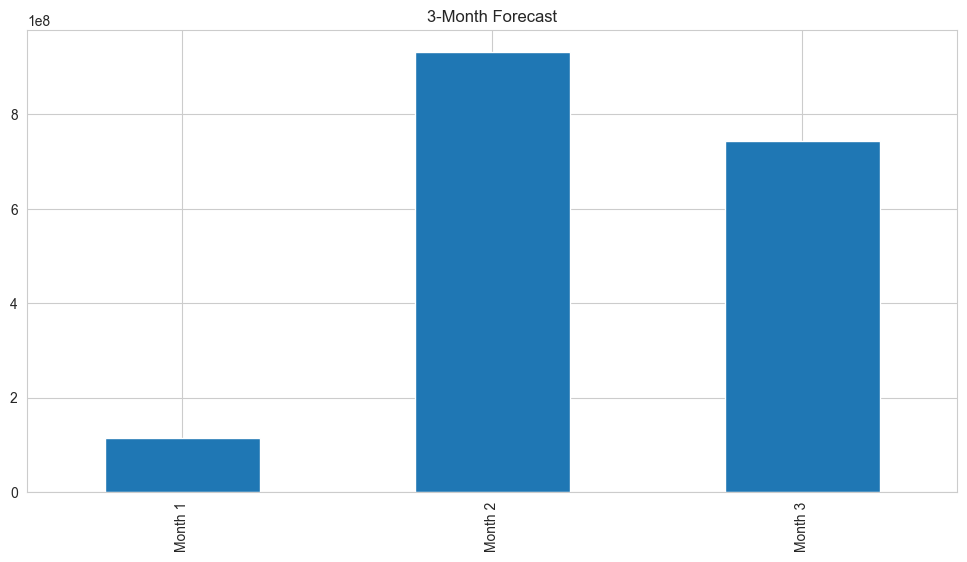

In [19]:
# Revenue Forecast
current_month_start = analysis_date.replace(day=1)
forecast = {'Month 1': 0, 'Month 2': 0, 'Month 3': 0}

# 1. Open Invoices
open_inv = df[df['status']=='Open']
for _, row in open_inv.iterrows():
    diff = (row['due_date'].year - current_month_start.year)*12 + (row['due_date'].month - current_month_start.month)
    if diff == 0: key = 'Month 1' 
    elif diff == 1: key = 'Month 2'
    elif diff == 2: key = 'Month 3'
    else: key = None
    if key: forecast[key] += row['amount_due'] * 0.95

# 2. Overdue (Recover 50% of recent <30 days)
overdue_inv = df[df['status']=='Overdue']
m1_collect = overdue_inv[overdue_inv['current_days_overdue'] < 30]['amount_due'].sum() * 0.5
forecast['Month 1'] += m1_collect

# 3. New Sales (Avg last 90 days)
last_90 = df['issue_date'].max() - timedelta(days=90)
avg_sales = df[df['issue_date'] > last_90]['total_amount'].sum() / 3
forecast['Month 2'] += avg_sales * 0.9
forecast['Month 3'] += avg_sales * 0.9

pd.Series(forecast).plot(kind='bar', title='3-Month Forecast')
print("Forecast Generated.")
